In [1]:
import logging
import warnings
from datetime import datetime
import os
import sys
import numpy as np
import pandas as pd
import matplotlib as mlp
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [131]:
today = datetime.now().date()

In [132]:
logging.basicConfig(
    level=logging.INFO, 
    format="%(asctime)s - %(levelname)s - %(message)s", 
    datefmt="%Y-%m-%d %H:%M:%S", 
    handlers=[
        logging.FileHandler(f"./logs/msc_data_generation_{today}.log", mode='w'), 
        logging.StreamHandler(sys.stdout)
    ]
)

Each of the subjects were shown a sequence of indoor and outdoor images each session. Now, normally, the order of this sequence is randomized. We need to hopefully find a few that are the same sequence of stimuli. We will know that those specific sessions should be the same. Thus, if $sub^{n}_{i}$, $sub^{n+x}_{j}$, and $sub^{n+y}_{k}$, with superscript referring to subject number and subscript referring to session number, all have the same sequence in their event files, we can assume that all differences between them can be discarded. We can also take the similarities between the discarded information as the inverse of the transformation all other sessions must go through to be in the same space.

In [133]:
# ---Variable Config---
config = {
    'data_dir': "../data/fmriprep_output/derivatives",
    'raw_dir': "../data/ds000224",
    'roi_mask_path': "./Sphere_Mask.nii",
    'subj_prefix': "sub-MSC",
    'sess_prefix': "ses-func",
    'task_label': "task-memoryscenes",
    'space_label': "space-MNI152NLin2009cAsym",
    'bold_suffix': "desc-preproc_bold.nii.gz",
    'mask_suffix': "desc-brain_mask.nii.gz",
    'confounds_suffix': "desc-confounds_timeseries.tsv",
    'events_suffix': 'events.tsv',
    'data_output_dir': 'datasets', 
    'roi_label': 'roi-fef_r',
    'encoding_label': 'encoding-continuous',
    'csv_suffix': 'desc-vox_w_target.csv',
    'nilearn_defaults': {
         'standardize': 'zscore_sample',
         'detrend': True,
         'low_pass': 0.1,
         'high_pass': 0.01,
         't_r': 2
        },
    'hrf_model': 'spm'
}

In [134]:
df_list = []
df_idx = []
for sub in range(1,11):
    if sub==10:
        sub = str(sub)
    else:
        sub = "0"+str(sub)
    
    for ses in range(1,15):
        if ses>9:
            ses = str(ses)
        else:
            ses = "0"+str(ses)

        p_events = os.path.join(config['raw_dir'], 
                        config['subj_prefix']+sub, 
                        config['sess_prefix']+ses, 
                        'func',  
                        "_".join([config['subj_prefix']+sub, 
                                  config['sess_prefix']+ses, 
                                  config['task_label'], 
                                  config['events_suffix']
                                 ]
                                )
                       )

        if not os.path.isfile(p_events):
            print(f"Failed: {p_events}")
            continue

        df = pd.read_csv(p_events, header=0, sep="\t")
        df['subj'] = [sub]*df.shape[0]
        df['sess'] = [ses]*df.shape[0]
        df_list.append(df)
        df_idx.append((len(df_list), sub, ses))
        print(f"Subject {sub}, session {ses}, accumulated dfs {len(df_list)}")

edf = pd.concat(df_list, axis=0, ignore_index=True)

Subject 01, session 01, accumulated dfs 1
Subject 01, session 02, accumulated dfs 2
Subject 01, session 03, accumulated dfs 3
Subject 01, session 04, accumulated dfs 4
Subject 01, session 05, accumulated dfs 5
Subject 01, session 06, accumulated dfs 6
Subject 01, session 07, accumulated dfs 7
Subject 01, session 08, accumulated dfs 8
Subject 01, session 09, accumulated dfs 9
Subject 01, session 10, accumulated dfs 10
Failed: ../data/ds000224/sub-MSC01/ses-func11/func/sub-MSC01_ses-func11_task-memoryscenes_events.tsv
Failed: ../data/ds000224/sub-MSC01/ses-func12/func/sub-MSC01_ses-func12_task-memoryscenes_events.tsv
Failed: ../data/ds000224/sub-MSC01/ses-func13/func/sub-MSC01_ses-func13_task-memoryscenes_events.tsv
Failed: ../data/ds000224/sub-MSC01/ses-func14/func/sub-MSC01_ses-func14_task-memoryscenes_events.tsv
Subject 02, session 01, accumulated dfs 11
Subject 02, session 02, accumulated dfs 12
Subject 02, session 03, accumulated dfs 13
Failed: ../data/ds000224/sub-MSC02/ses-func04/

In [135]:
trial_type_labels = dict(zip(edf.trial_type.unique(),np.arange(edf.trial_type.unique().shape[0])))
X = [df['trial_type'].map(trial_type_labels).to_numpy() for df in df_list]

In [136]:
unique_seqs = {}
for i, seq in enumerate(X):
    seq_key = tuple(seq)
    if seq_key not in unique_seqs.keys():
        unique_seqs[seq_key] = []
    unique_seqs[seq_key].append(i)

In [137]:
len(unique_seqs.keys())<len(X)

True

Okay! At least two sequences match!

In [138]:
matches = [seq for seq in unique_seqs if len(unique_seqs[seq])>1]

In [139]:
print(f"We found {len(matches)} unique sequences that were presented multiple times!")

We found 6 unique sequences that were presented multiple times!


---

Now we have to go map the matching sequences and see what we get! First, we have to find the matching runs, then the sub/sess for the runs, then we have to perform pca, then t-sne, then visualize.

In [140]:
run_groups = []
for match in matches:
    print(f"Sequences from runs {unique_seqs[match]} match!")
    run_groups.append(unique_seqs[match])

Sequences from runs [0, 28] match!
Sequences from runs [3, 21, 41, 51, 61] match!
Sequences from runs [5, 33] match!
Sequences from runs [25, 45] match!
Sequences from runs [29, 79, 89] match!
Sequences from runs [34, 84] match!


In [141]:
subj_sess_idx = [[df_list[run][['subj', 'sess']].loc[0,].astype(int).to_list() for run in runs] for runs in run_groups]

In [142]:
subj_sess_idx

[[[1, 1], [4, 1]],
 [[1, 4], [3, 4], [5, 4], [6, 4], [7, 4]],
 [[1, 6], [4, 6]],
 [[3, 8], [5, 8]],
 [[4, 2], [9, 2], [10, 2]],
 [[4, 7], [9, 7]]]

---

In [2]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px

In [3]:
from matplotlib.colors import XKCD_COLORS

In [23]:
fdf = pd.read_csv("./full_fef_dataset3.csv", header=0, index_col=0)

In [146]:
seq1 = fdf[((fdf['subj']==subj_sess_idx[0][0][0]) & (fdf['sess']==subj_sess_idx[0][0][1])) | ((fdf['subj']==subj_sess_idx[0][1][0]) & (fdf['sess']==subj_sess_idx[0][1][1]))]
seq1.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v116,v117,v118,v119,target,indoor,outdoor,sess,subj,run
0,0.0,-0.000021,0.000011,0.00001,0.000000,0.000000,0.000000,-0.000009,0.00001,0.000032,...,0.000010,-0.000072,0.000000,-0.000009,0.0,0.0,0.0,1,1,1
1,2.2,-0.000021,0.000021,0.00001,0.000000,0.000000,0.000000,-0.000009,0.00001,0.000032,...,0.000010,-0.000072,0.000000,0.000000,0.0,0.0,0.0,1,1,1
2,4.4,-0.000031,0.000011,0.00001,0.000010,-0.000011,-0.000011,-0.000009,0.00001,0.000043,...,0.000000,-0.000072,0.000000,-0.000018,0.0,0.0,0.0,1,1,1
3,6.6,-0.000021,0.000021,0.00000,-0.000010,0.000011,0.000011,0.000000,0.00001,0.000011,...,0.000019,-0.000072,0.000010,0.000026,0.0,0.0,0.0,1,1,1
4,8.8,-0.000042,0.000000,0.00002,0.000031,-0.000033,-0.000021,-0.000019,0.00002,0.000074,...,-0.000019,-0.000072,-0.000019,-0.000061,0.0,0.0,0.0,1,1,1


In [147]:
x = seq1.drop(['target', 'indoor', 'outdoor', 'scan_time', 'sess', 'subj', 'run'], axis=1)
# x_norm = StandardScaler().fit_transform(x)
y = seq1[['indoor', 'outdoor']]

In [148]:
pca = PCA()
pca_x = pca.fit_transform(x)

In [149]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

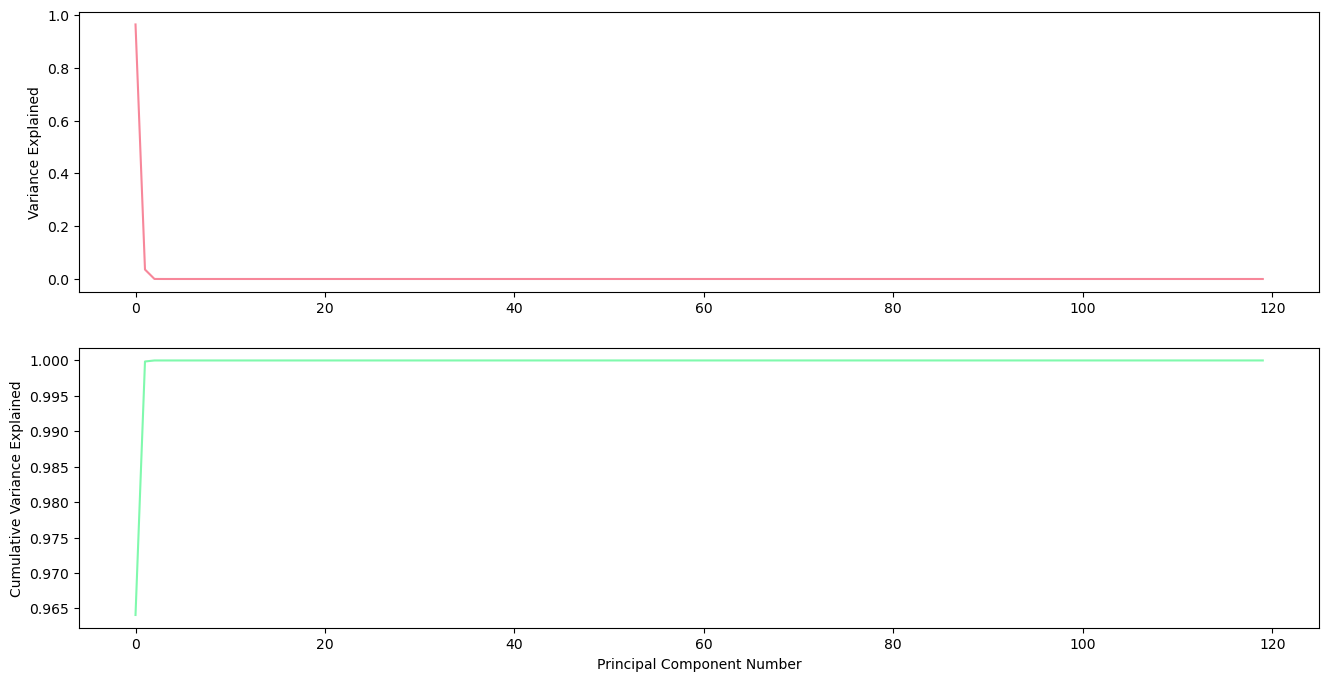

In [150]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

This actually makes a lot of sense for a dataset where both subjects saw the same sequence of events.

In [151]:
cum_exp_var[:10]

array([0.9640583 , 0.99985291, 0.99999764, 0.9999977 , 0.99999776,
       0.99999781, 0.99999786, 0.99999792, 0.99999797, 0.99999802])

In [152]:
x10pc = pca_x[:,0:10]

In [153]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(x10pc)

In [154]:
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = seq1['scan_time'].to_list()
tsne_df['Subjects'] = seq1['subj'].to_list()
tsne_df['Run'] = seq1['run'].to_list()
tsne_df['Session'] = seq1['sess'].to_list()

In [155]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Subjects', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Subject")
fig.show(renderer="iframe")

In [156]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Time', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Scan Time")
fig.show(renderer="iframe")

In [161]:
seq2 = fdf[((fdf['subj']==subj_sess_idx[1][0][0]) & 
            (fdf['sess']==subj_sess_idx[1][0][1])) | ((fdf['subj']==subj_sess_idx[1][1][0]) & 
                                                      (fdf['sess']==subj_sess_idx[1][1][1])) | ((fdf['subj']==subj_sess_idx[1][2][0]) & 
                                                                                                (fdf['sess']==subj_sess_idx[1][2][1])) | ((fdf['subj']==subj_sess_idx[1][3][0]) & 
                                                                                                                                          (fdf['sess']==subj_sess_idx[1][3][1])) | ((fdf['subj']==subj_sess_idx[1][4][0]) & 
                                                                                                                                                                                    (fdf['sess']==subj_sess_idx[1][4][1]))]
seq2.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v116,v117,v118,v119,target,indoor,outdoor,sess,subj,run
363,0.0,0.000065,0.00000,-0.000018,0.000000,0.00000,0.000037,-0.000017,-0.000061,0.000000,...,0.000017,-0.000018,0.000017,0.000008,0.0,0.0,0.0,4,1,4
364,2.2,0.000065,0.00000,-0.000018,0.000000,0.00000,0.000037,-0.000017,-0.000061,0.000009,...,0.000009,-0.000027,0.000017,0.000008,0.0,0.0,0.0,4,1,4
365,4.4,0.000065,0.00000,-0.000018,-0.000009,-0.00001,0.000037,-0.000017,-0.000061,0.000000,...,0.000017,-0.000018,0.000017,0.000016,0.0,0.0,0.0,4,1,4
366,6.6,0.000065,-0.00001,-0.000018,0.000009,0.00001,0.000028,-0.000025,-0.000061,0.000009,...,0.000009,-0.000035,0.000009,0.000000,0.0,0.0,0.0,4,1,4
367,8.8,0.000065,0.00001,-0.000027,-0.000018,-0.00002,0.000046,-0.000008,-0.000061,0.000000,...,0.000026,0.000009,0.000026,0.000033,0.0,0.0,0.0,4,1,4


In [162]:
x = seq2.drop(['target', 'indoor', 'outdoor', 'scan_time', 'sess', 'subj', 'run'], axis=1)
# x_norm = StandardScaler().fit_transform(x)
y = seq2[['indoor', 'outdoor']]

In [82]:
pca = PCA()
pca_x = pca.fit_transform(x)

In [83]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

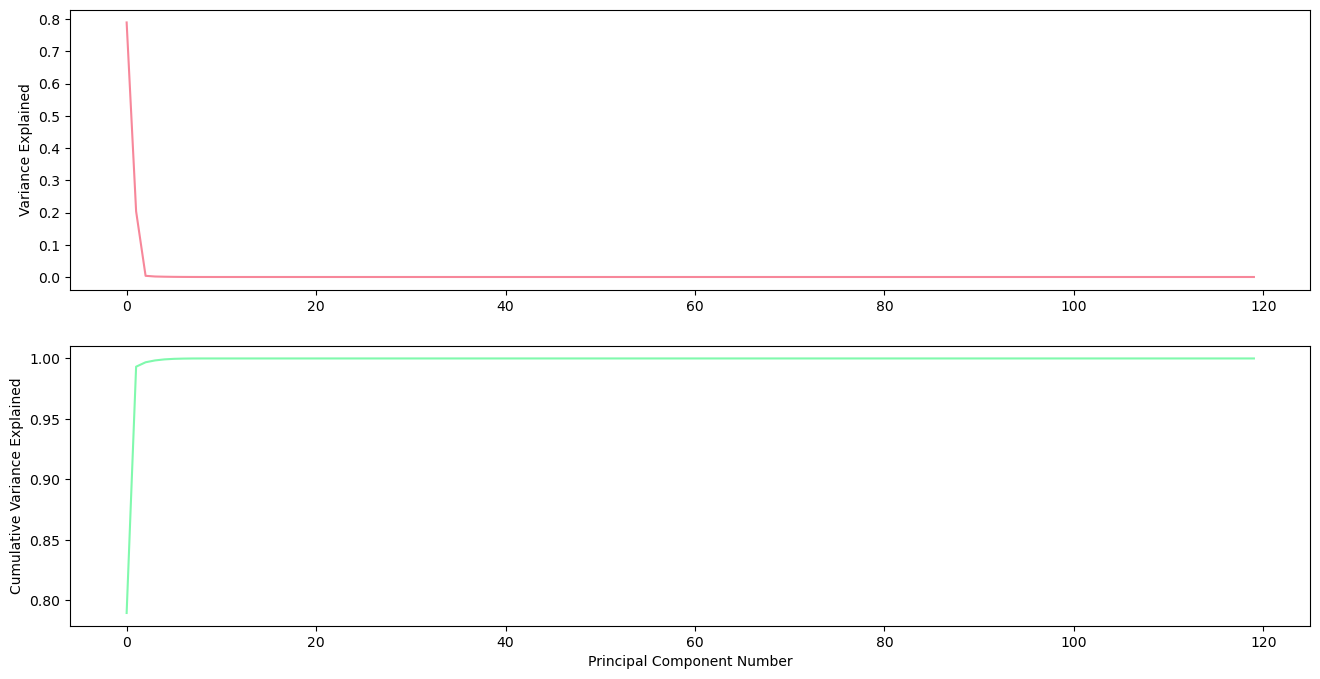

In [84]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

In [85]:
cum_exp_var[:10]

array([0.78957856, 0.99319851, 0.99683568, 0.99837488, 0.99923587,
       0.99967765, 0.99988413, 0.99997706, 0.99999515, 0.99999529])

In [86]:
x10pc = pca_x[:,0:10]

In [89]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(x10pc)

In [95]:
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = seq2['scan_time'].to_list()
tsne_df['Subjects'] = seq2['subj'].to_list()
tsne_df['Run'] = seq2['run'].to_list()
tsne_df['Session'] = seq2['sess'].to_list()
tsne_df['Target'] = seq2['target'].to_list()

In [92]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Subjects', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Subject")
fig.show(renderer="iframe")

In [93]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Time', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Scan Time")
fig.show(renderer="iframe")

In [96]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Target', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor to Outdoor Strength")
fig.show(renderer="iframe")

In [99]:
tsne_df['Indoor'] = seq2['indoor'].to_list()
tsne_df['Outdoor'] = seq2['outdoor'].to_list()
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Indoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [100]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Outdoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [103]:
x10pcdf = pd.DataFrame(dict(zip(['PC'+str(n) for n in np.arange(10)], [x10pc[:,n] for n in np.arange(x10pc.shape[1])])))
x10pcdf['Time'] = seq2['scan_time'].to_list()
x10pcdf['Subjects'] = seq2['subj'].to_list()
x10pcdf['Run'] = seq2['run'].to_list()
x10pcdf['Session'] = seq2['sess'].to_list()
x10pcdf['Target'] = seq2['target'].to_list()
x10pcdf['Indoor'] = seq2['indoor'].to_list()
x10pcdf['Outdoor'] = seq2['outdoor'].to_list()
fig = px.scatter_3d(x10pcdf, x='PC0', y='PC1', z='PC2', color='Indoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [105]:
fig = px.scatter_3d(x10pcdf, x='PC0', y='PC1', z='PC2', color='Outdoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Outdoor Strength")
fig.show(renderer="iframe")

In [106]:
fig = px.scatter_3d(x10pcdf, x='PC0', y='PC1', z='PC2', color='Target', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [107]:
fig = px.scatter_3d(x10pcdf, x='PC3', y='PC1', z='PC2', color='Target', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [112]:
fig = px.scatter_3d(x10pcdf, x='PC3', y='PC1', z='PC2', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

In [111]:
fig = px.scatter_3d(x10pcdf, x='PC3', y='PC4', z='PC2', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

In [113]:
fig = px.scatter_3d(x10pcdf, x='PC3', y='PC4', z='PC5', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

In [114]:
fig = px.scatter_3d(x10pcdf, x='PC6', y='PC4', z='PC5', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

This needs some more preprocessing.

---------------

In [4]:
from sklearn.preprocessing import StandardScaler
from scipy.linalg import orthogonal_procrustes

In [163]:
x = fdf.drop(['target', 'indoor', 'outdoor', 'scan_time', 'sess', 'subj', 'run'], axis=1)
# x_norm = StandardScaler().fit_transform(x)
y = fdf[['indoor', 'outdoor']]

In [7]:
for run in fdf['run'].unique():
    idx_run = fdf.index[fdf['run']==run].to_list()
    scaler = StandardScaler()
    x.loc[idx_run,:] = scaler.fit_transform(x.loc[idx_run,:])

Just need a quick and dirty update of seq2.

In [164]:
update_cols = list(set(seq2.columns).intersection(x.columns))
len(update_cols)

120

In [165]:
seq2.loc[:,update_cols] = x.loc[seq2.index,:]

In [166]:
seq2.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v116,v117,v118,v119,target,indoor,outdoor,sess,subj,run
363,0.0,0.000065,0.00000,-0.000018,0.000000,0.00000,0.000037,-0.000017,-0.000061,0.000000,...,0.000017,-0.000018,0.000017,0.000008,0.0,0.0,0.0,4,1,4
364,2.2,0.000065,0.00000,-0.000018,0.000000,0.00000,0.000037,-0.000017,-0.000061,0.000009,...,0.000009,-0.000027,0.000017,0.000008,0.0,0.0,0.0,4,1,4
365,4.4,0.000065,0.00000,-0.000018,-0.000009,-0.00001,0.000037,-0.000017,-0.000061,0.000000,...,0.000017,-0.000018,0.000017,0.000016,0.0,0.0,0.0,4,1,4
366,6.6,0.000065,-0.00001,-0.000018,0.000009,0.00001,0.000028,-0.000025,-0.000061,0.000009,...,0.000009,-0.000035,0.000009,0.000000,0.0,0.0,0.0,4,1,4
367,8.8,0.000065,0.00001,-0.000027,-0.000018,-0.00002,0.000046,-0.000008,-0.000061,0.000000,...,0.000026,0.000009,0.000026,0.000033,0.0,0.0,0.0,4,1,4


From our analysis above, we know that these strands are not aligned. First, let's check how they look. Then we gotta compute the transformation matrix that aligns one strand to another. 

In [171]:
pca = PCA()
pca_seq2 = pca.fit_transform(seq2.loc[:,update_cols])

In [172]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

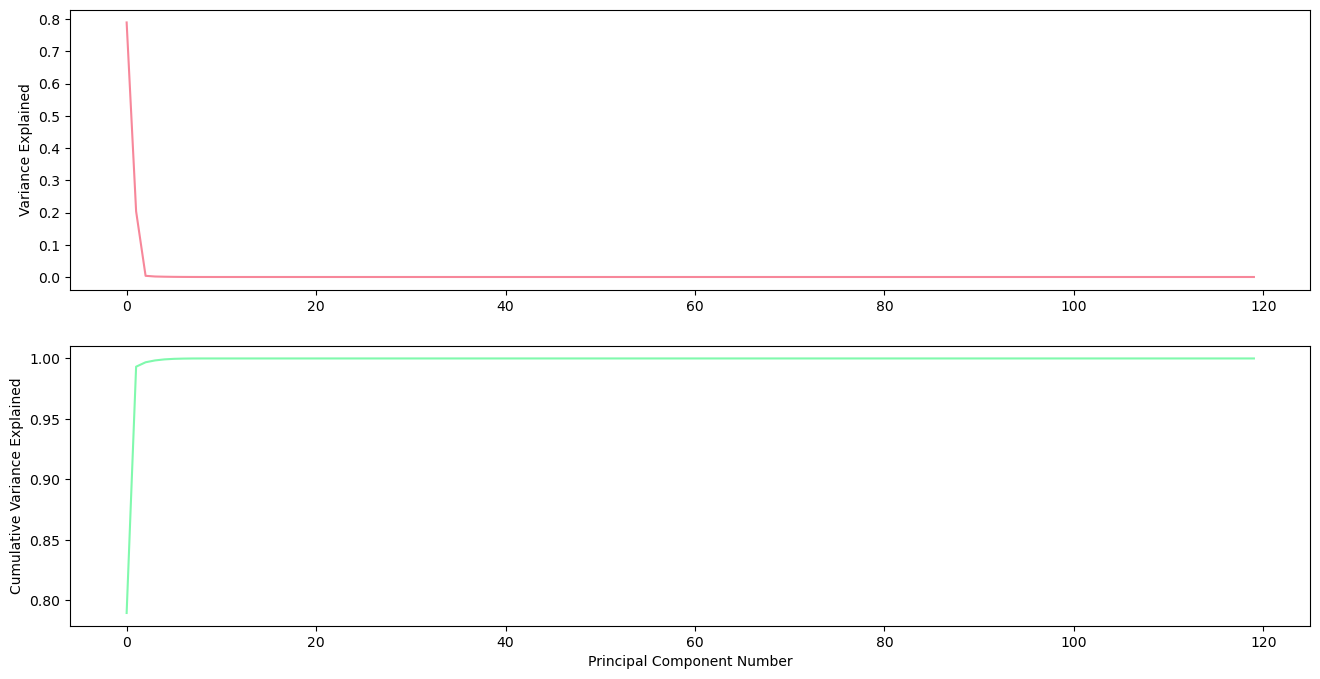

In [173]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

In [25]:
cum_exp_var[:25]

array([0.33085579, 0.5495959 , 0.7130226 , 0.86013937, 0.96293217,
       0.97007334, 0.97510587, 0.97858715, 0.98099955, 0.98326919,
       0.98497159, 0.9863099 , 0.98748615, 0.98861302, 0.98959094,
       0.99053152, 0.99131702, 0.99202199, 0.99253528, 0.99302045,
       0.9934851 , 0.99390723, 0.99427824, 0.99462513, 0.99495011])

In [174]:
x5pc = pca_seq2[:,0:5]

In [175]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(x5pc)

In [176]:
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = seq2['scan_time'].to_list()
tsne_df['Subjects'] = seq2['subj'].to_list()
tsne_df['Run'] = seq2['run'].to_list()
tsne_df['Session'] = seq2['sess'].to_list()
tsne_df['Target'] = seq2['target'].to_list()

In [177]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Subjects', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Subject")
fig.show(renderer="iframe")

In [195]:
s2idx = [seq2[seq2['subj']==x].index.to_list() for x in x5pcdf.Subjects.unique()]

In [221]:
master_tmat_list = []
master_corr_list = []

for i, s in enumerate(x5pcdf.Subjects.unique()):
    
    tmat_list = []
    corr_list = []
    target = x.loc[s2idx[i],:].to_numpy()
    
    for run in s2idx:
        transforming_matrix = x.loc[run,:].to_numpy()
        
        transformation_matrix, _ = orthogonal_procrustes(transforming_matrix, target)
        transformed_matrix = transforming_matrix @ transformation_matrix
        tmat_list.append(transformation_matrix)
        ccf = np.corrcoef(transformed_matrix.flatten(),target.flatten())[0,1]
        if ccf > .9999999998:
            continue
        corr_list.append(ccf)

    master_tmat_list.append((s, tmat_list))
    master_corr_list.append((s, corr_list))


In [222]:
for item in master_corr_list:
    print(f"Best alignment for subject {item[0]} is {max(item[1])}")

Best alignment for subject 1 is 0.992808578706741
Best alignment for subject 3 is 0.49829948832839993
Best alignment for subject 5 is 0.4981339913640145
Best alignment for subject 6 is 0.9928090237458693
Best alignment for subject 7 is 0.30254062797424064


Let's do it for everyone!  Woohoo!!

In [225]:
x_w_id['Run'] = fdf['run'].copy()
x_w_id.head()

,v0,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v114,v115,v116,v117,v118,v119,Subject,Session,Time,Run
0,0.002626,-0.003498,-0.000320,-0.000469,0.001563,0.001647,-0.002985,-0.000599,-0.000111,0.002228,...,0.000822,0.002005,0.001574,0.023632,0.000045,-0.000755,1,1,0.0,1
1,0.002626,0.003799,-0.000320,-0.000469,0.001563,0.001647,-0.002985,-0.000599,-0.000111,0.002228,...,0.000822,0.002005,0.001574,0.023632,0.000045,0.001072,1,1,2.2,1
2,-0.004595,-0.003498,-0.000320,0.003582,-0.003164,-0.004997,-0.002985,-0.000599,0.003246,-0.005476,...,0.000822,0.002005,-0.002567,0.023632,0.000045,-0.002581,1,1,4.4,1
3,0.002626,0.003799,-0.009998,-0.004520,0.006289,0.008291,0.005223,-0.000599,-0.006826,0.002228,...,0.000822,-0.005131,0.005716,0.023632,0.005460,0.006550,1,1,6.6,1
4,-0.011816,-0.010795,0.009358,0.011684,-0.012618,-0.011640,-0.011193,0.023550,0.013318,-0.013180,...,0.000822,0.009141,-0.010849,0.023632,-0.010786,-0.011711,1,1,8.8,1


In [60]:
master_tmat_list = []
master_corr_list = []
corr_sum_list = []
for s in sfdf['Subject'].unique():
    
    tmat_list = []
    corr_list = []
    target = sfdf[sfdf['Subject']==s].drop(columns=['Subject', 'Session', 'Run']).to_numpy()
    target = np.matmul(target.T,target)
    
    for t in sfdf['Subject'].unique():
        transforming_matrix = sfdf[sfdf['Subject']==t].drop(columns=['Subject', 'Session', 'Run']).to_numpy()
        
        transforming_matrix = np.matmul(transforming_matrix.T,transforming_matrix)
        print(transforming_matrix.shape, target.shape)
        transformation_matrix, _ = orthogonal_procrustes(transforming_matrix, target)
        transformed_matrix = transforming_matrix @ transformation_matrix
        tmat_list.append((t, transformation_matrix))
        ccf = np.corrcoef(transformed_matrix.flatten(),target.flatten())[0,1]
        corr_list.append((t, ccf))

    master_tmat_list.append((s, tmat_list))
    master_corr_list.append((s, corr_list))
    corr_sum_list.append((s, sum([nt[1] for nt in corr_list])))


(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120) (120, 120)
(120, 120)

In [59]:
target.min()

np.float64(nan)

In [239]:
import pickle

with open('tmat.pkl', 'wb') as file:
    pickle.dump(master_tmat_list, file)
    
with open('corr.pkl', 'wb') as file:
    pickle.dump(master_corr_list, file)

with open('sumcorr.pkl', 'wb') as file:
    pickle.dump(corr_sum_list, file)

-------

In [24]:
sfdf = pd.read_csv("./dataset_3_FEF_scaled_by_run.csv", header=0, index_col=0)

In [5]:
import pickle

with open('tmat.pkl', 'rb') as file:
    master_tmat_list = pickle.load(file)
    
with open('corr.pkl', 'rb') as file:
    master_corr_list = pickle.load(file)

with open('sumcorr.pkl', 'rb') as file:
    corr_sum_list = pickle.load(file)

In [61]:
np.where(corr_sum_list==max([nt[1] for nt in corr_sum_list]))

(array([0]), array([1]))

It would seem that run 57 is the one that aligns well with everyone. Let's align everyone to that one and go plot!

In [62]:
corr_sum_list

[(np.int64(1), np.float64(3.110536874803602)),
 (np.int64(2), np.float64(2.945714905325268)),
 (np.int64(3), np.float64(2.9767937734567194)),
 (np.int64(4), np.float64(3.0545236797389714)),
 (np.int64(5), np.float64(3.082060056197988)),
 (np.int64(6), np.float64(3.0892196097423823)),
 (np.int64(7), np.float64(2.9334728253913496)),
 (np.int64(8), np.float64(3.0634564838273235)),
 (np.int64(9), np.float64(3.0439254127087647)),
 (np.int64(10), np.float64(3.0477289581596656))]

In [66]:
master_tmat_list[0][1][5]#[1]

(np.int64(6),
 array([[ 0.7828131 ,  0.05655155,  0.00862906, ...,  0.0736872 ,
          0.05160019, -0.00157459],
        [-0.02383417,  0.69806211, -0.08354   , ..., -0.01151879,
         -0.08152599, -0.06999558],
        [ 0.05187926,  0.0574655 ,  0.6908198 , ...,  0.00934901,
         -0.01378324, -0.1367762 ],
        ...,
        [-0.0837863 ,  0.0485556 ,  0.05518921, ...,  0.63396976,
          0.04610744, -0.00306042],
        [-0.02292691,  0.05087874,  0.04101289, ..., -0.03209928,
          0.74626513, -0.01376231],
        [ 0.04163971,  0.15485106,  0.1324766 , ..., -0.02529974,
          0.00209304,  0.76215334]], shape=(120, 120)))

Honestly, I should've also saved the transformations. But alas!

In [84]:
x_proc = sfdf.copy()

for i, s in enumerate(fdf['subj'].unique()):
    transformation_matrix = master_tmat_list[0][1][i][1] # the template transformations
    transforming_matrix = sfdf.loc[fdf[fdf['subj']==s].index,:].to_numpy()
    transformed_matrix = transforming_matrix @ transformation_matrix
    x_proc.loc[fdf[fdf['subj']==s].index,:] = transformed_matrix
   
x_proc['Subject'] = fdf['subj']
x_proc['Session'] = fdf['sess']
x_proc['Run'] = fdf['run']

In [99]:
pca = PCA()
pca_x_proc = pca.fit_transform(x_proc.drop(columns=['Subject', 'Session', 'Run']))

In [100]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

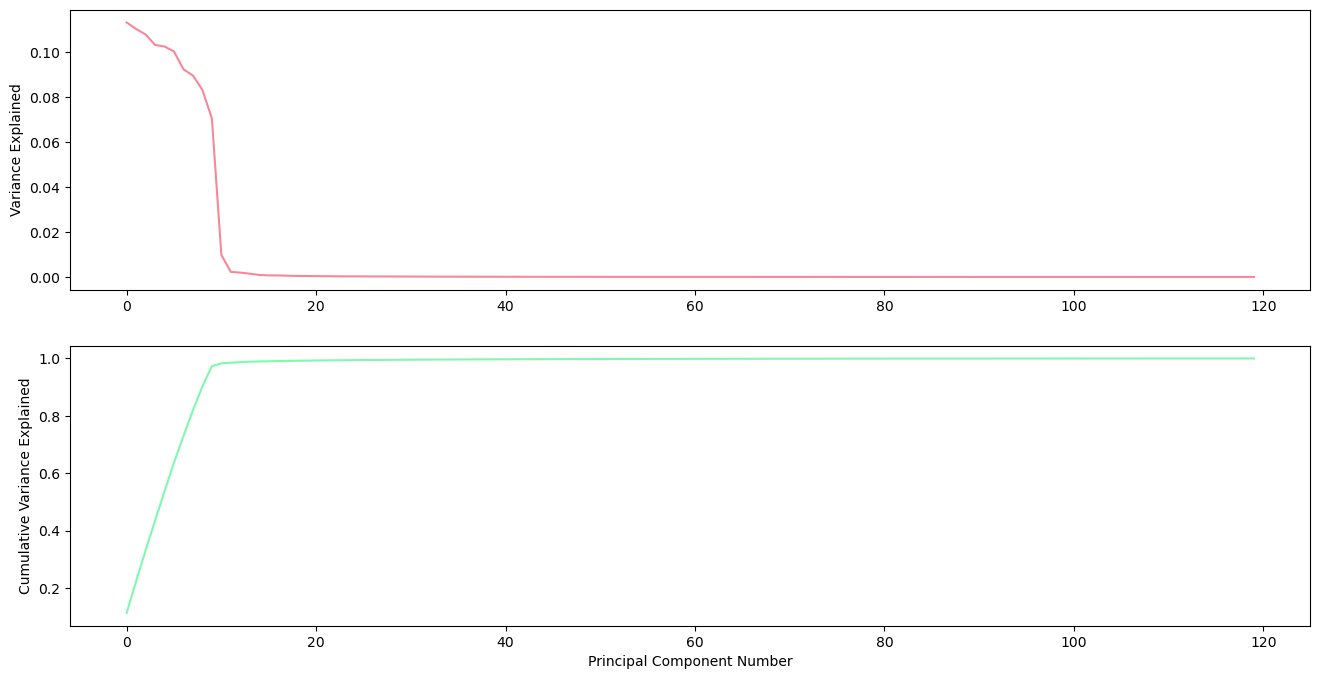

In [101]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

In [104]:
exp_var[:10]

array([0.11321789, 0.1103382 , 0.10787686, 0.10322785, 0.10251373,
       0.10028063, 0.09238452, 0.08960474, 0.08317514, 0.07052165])

In [105]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(pca_x_proc[:,:10])

In [109]:
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = fdf['scan_time']
tsne_df['Run'] = fdf['run']
tsne_df['Subject'] = fdf['subj']
tsne_df['Session'] = fdf['sess']

In [110]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Subject', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Subject")
fig.show(renderer="iframe")

In [111]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Session', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Session")
fig.show(renderer="iframe")

In [112]:
tsne_df['Indoor'] = fdf['indoor']
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Indoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [113]:
x_proc.to_csv("./datasets/scaled_procrustes_transformed_by_subject_rfef.csv")

Let's also take a look at how the principle components look.

In [180]:
x5pcdf = pd.DataFrame(dict(zip(['PC'+str(n) for n in np.arange(25)], [x5pc[:,n] for n in np.arange(x5pc.shape[1])])))
x5pcdf['Time'] = seq2['scan_time'].to_list()
x5pcdf['Subjects'] = seq2['subj'].to_list()
x5pcdf['Run'] = seq2['run'].to_list()
x5pcdf['Session'] = seq2['sess'].to_list()
x5pcdf['Target'] = seq2['target'].to_list()
x5pcdf['Indoor'] = seq2['indoor'].to_list()
x5pcdf['Outdoor'] = seq2['outdoor'].to_list()
fig = px.scatter_3d(x5pcdf, x='PC0', y='PC1', z='PC2', color='Indoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [181]:
fig = px.scatter_3d(x5pcdf, x='PC0', y='PC1', z='PC2', color='Outdoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Outdoor Strength")
fig.show(renderer="iframe")

In [182]:
fig = px.scatter_3d(x5pcdf, x='PC0', y='PC1', z='PC2', color='Target', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [183]:
fig = px.scatter_3d(x5pcdf, x='PC3', y='PC1', z='PC2', color='Target', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [184]:
fig = px.scatter_3d(x5pcdf, x='PC3', y='PC1', z='PC2', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

In [185]:
fig = px.scatter_3d(x5pcdf, x='PC3', y='PC4', z='PC2', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

In [189]:
fig = px.scatter_3d(x5pcdf, x='PC0', y='PC1', z='PC2', color='Time', opacity=0.7, size_max=3, title="PCA of FEF by Scan Time")
fig.show(renderer="iframe")

Let's see how this looks when drawn.

In [190]:
from mpl_toolkits.mplot3d import Axes3D

In [191]:
xkcd_keys = list(XKCD_COLORS.keys())

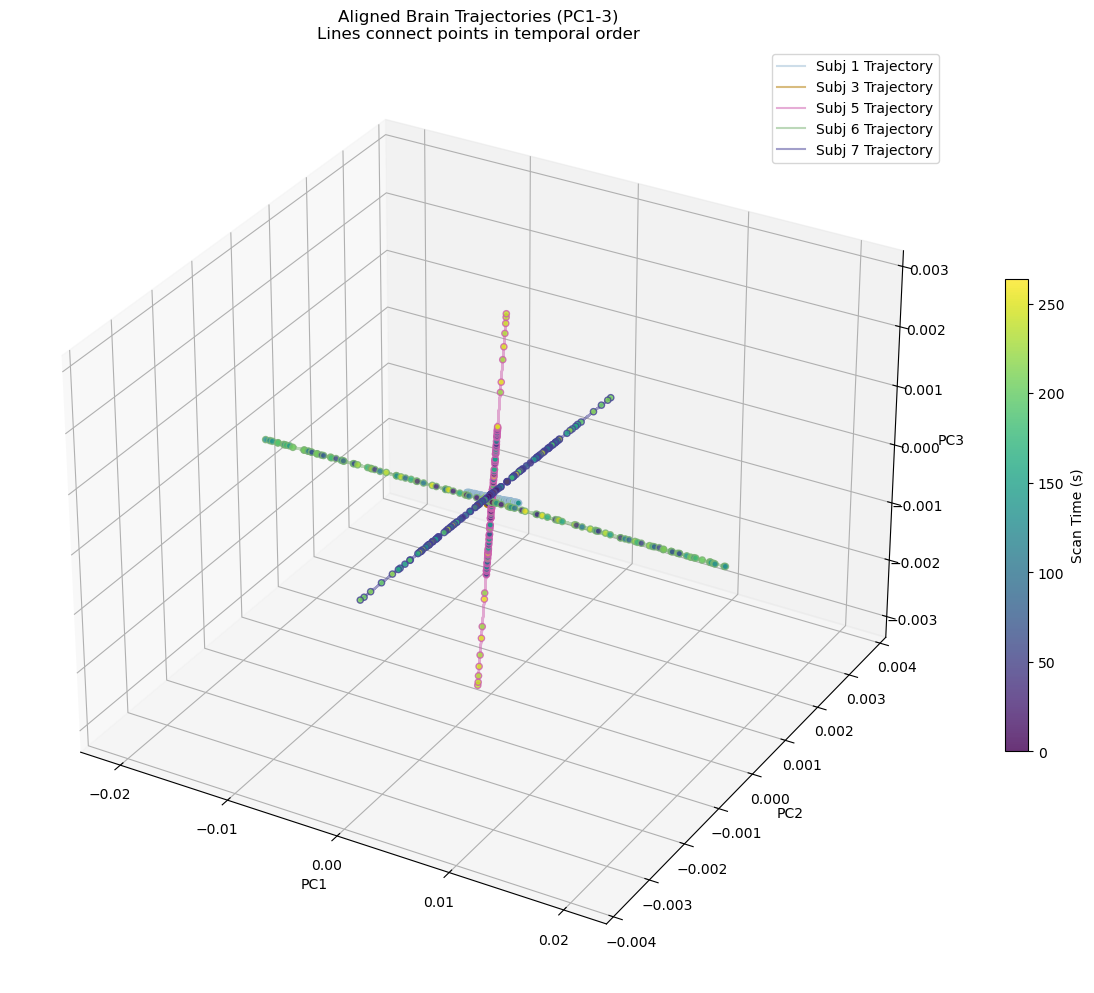

In [192]:
# ax.plot3D(xs, ys, zs, color=XKCD_COLORS["xkcd:seafoam"], linestyle=line_styles[i], alpha=0.5, label=f'Trajectory Subj {s_id}')

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Choose subjects to plot
plot_subjects = x5pcdf['Subjects'].unique()
rng = np.random.default_rng()
color_choices = rng.integers(len(XKCD_COLORS.keys()), size=len(plot_subjects))
colors = [XKCD_COLORS[xkcd_keys[c]] for c in color_choices] # Line colors
labels = ['Subj '+str(s) for s in plot_subjects]

for s, base_color, label in zip(plot_subjects, colors, labels):
    subset = x5pcdf[x5pcdf['Subjects'] == s]#.sort_values('scan_time')
    
    xs = subset['PC1']
    ys = subset['PC2']
    zs = subset['PC3']
    times = subset['Time']
    
    # A. Draw the LINE (Trajectory)
    # This connects the points in order
    ax.plot(xs, ys, zs, color=base_color, alpha=0.5, label=f'{label} Trajectory')
    
    # B. Draw the POINTS (Time Dimension)
    # Color by time to show the "4th dimension"
    # We use a scatter plot on top of the line
    sc = ax.scatter(xs, ys, zs, c=times, cmap='viridis', s=20, edgecolors=base_color, alpha=0.8)

# Add colorbar for time
cbar = plt.colorbar(sc, ax=ax, shrink=0.5)
cbar.set_label('Scan Time (s)')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Aligned Brain Trajectories (PC1-3)\nLines connect points in temporal order')
ax.legend()

plt.tight_layout()

This...was not that helpful. Let's try a different method.

In [7]:
import matplotlib.animation as animation
%matplotlib ipympl

In [18]:
def create_brain_animation(df, subject_id, session_id, filename='brain_movie.gif'):
    # Filter data for one subject
    data = df[(df['Subjects']==subject_id) & (df['Session']==session_id)]
    
    # Extract coordinates (PC1, PC2, PC3)
    xs = data['x'].values
    ys = data['y'].values
    zs = data['z'].values
    n_steps = len(xs)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Initialize Line (Trail) and Scatter (Head)
    line, = ax.plot([], [], [], color='blue', alpha=0.5)
    head = ax.scatter([], [], [], color='red', s=100) # Current thought is Red
    
    # Set Limits (Static box size)
    ax.set_xlim(df['x'].min(), df['x'].max())
    ax.set_ylim(df['y'].min(), df['y'].max())
    ax.set_zlim(df['z'].min(), df['z'].max())
    ax.set_title(f'Subject {subject_id} Trajectory for Session {session_id}')

    def update(num):
        # Update the line (History)
        line.set_data(xs[:num], ys[:num])
        line.set_3d_properties(zs[:num])
        
        # Update the head (Current Moment)
        # Note: scatter._offsets3d expects a tuple of arrays
        head._offsets3d = (xs[num-1:num], ys[num-1:num], zs[num-1:num])
        return line, head

    ani = animation.FuncAnimation(fig, update, frames=n_steps, interval=10, blit=False)
    ani.save(filename, writer='pillow', fps=15)
    plt.close()
    print(f"Saved {filename}")

Saved brain_movie_1.gif
Saved brain_movie_3.gif
Saved brain_movie_5.gif
Saved brain_movie_6.gif
Saved brain_movie_7.gif


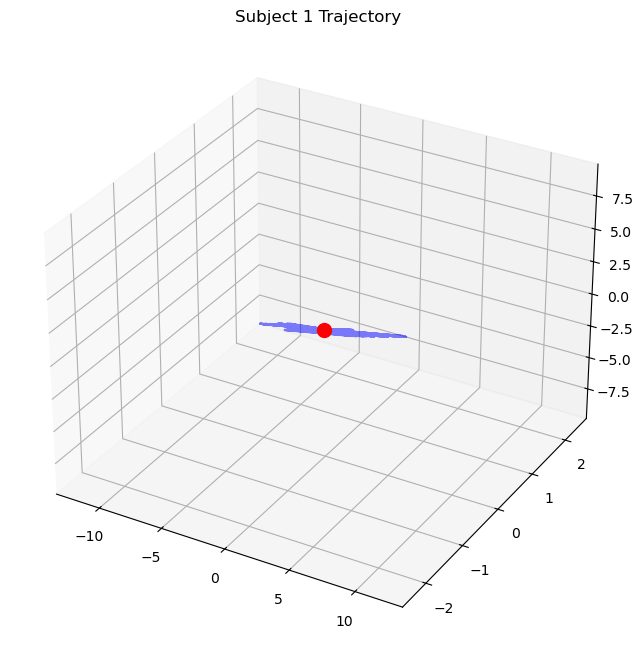

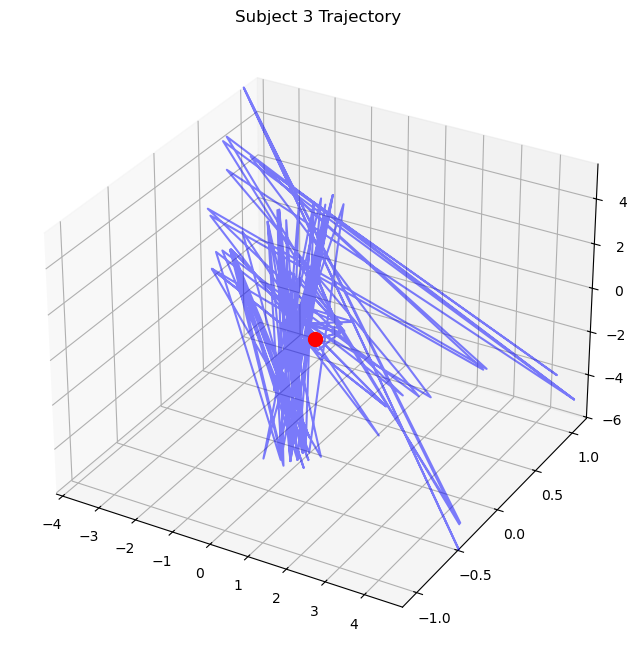

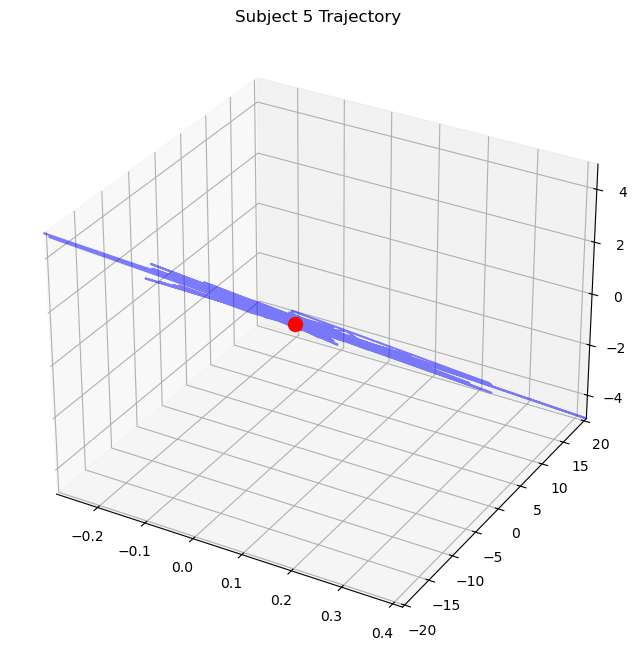

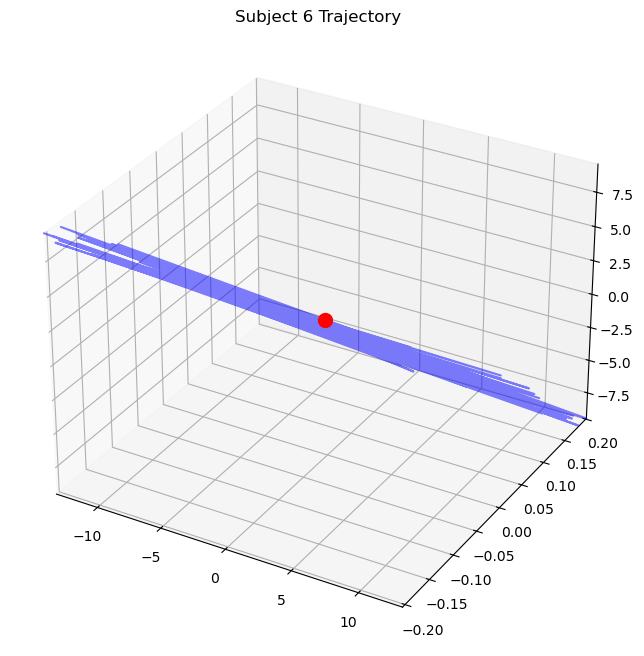

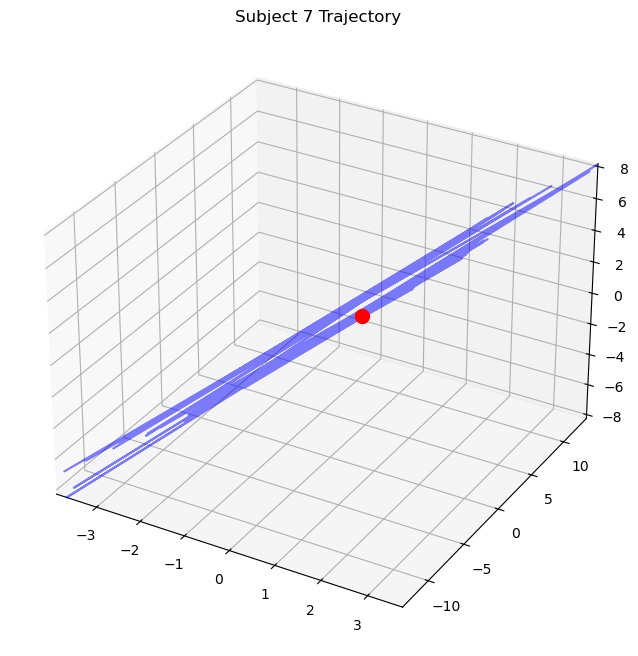

In [123]:
for s in plot_subjects:
    create_brain_animation(x5pcdf, s, filename=f'brain_movie_{s}.gif')

Well, would you look at that.

In [10]:
x = fdf.drop(['target', 'indoor', 'outdoor', 'scan_time', 'sess', 'subj', 'run'], axis=1)
y = fdf[['indoor', 'outdoor']]

In [11]:
for run in fdf['run'].unique():
    idx_run = fdf.index[fdf['run']==run].to_list()
    scaler = StandardScaler()
    x.loc[idx_run,:] = scaler.fit_transform(x.loc[idx_run,:])

In [12]:
x.to_csv("./dataset_3_FEF_scaled_by_run.csv")

In [20]:
x = pd.read_csv("./dataset_3_FEF_scaled_by_run.csv", index_col=0, header=0)

In [21]:
pca = PCA()
pca_x = pca.fit_transform(x)

In [22]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

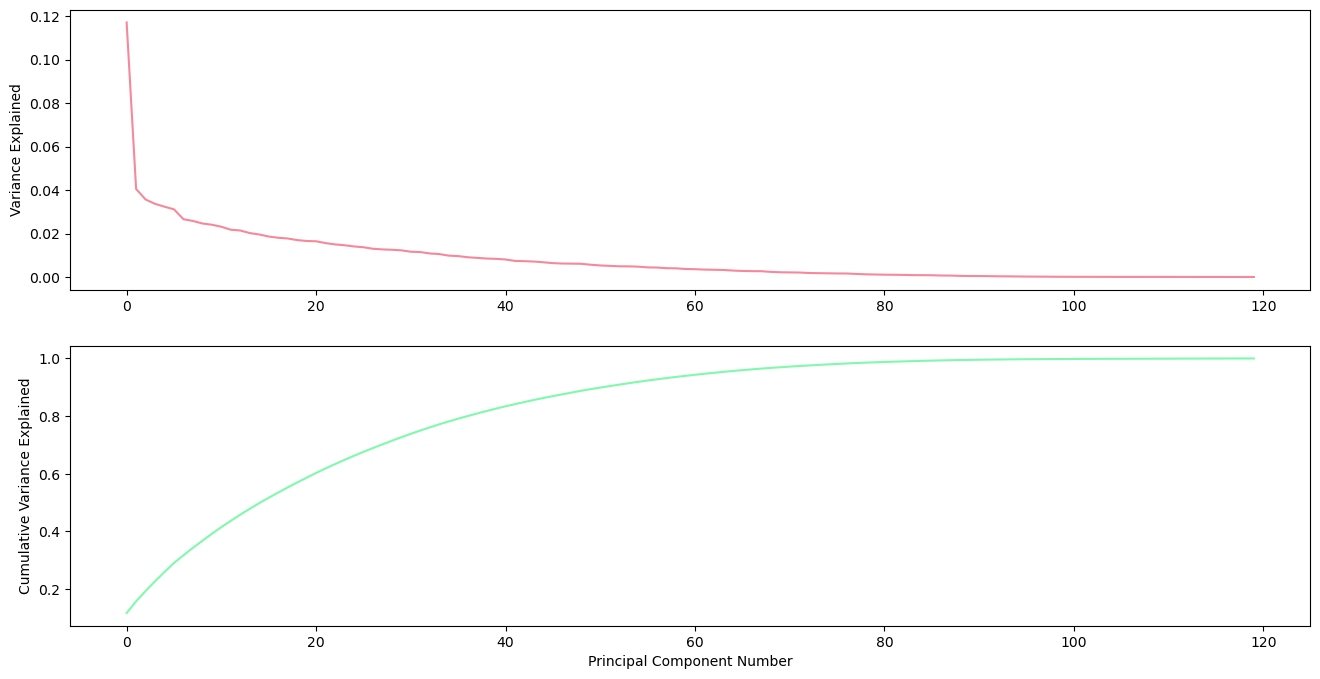

In [23]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

In [24]:
cum_exp_var[62]

np.float64(0.9502210653729218)

In [25]:
sum(exp_var[:63])

np.float64(0.9502210653729218)

In [26]:
pca.explained_variance_[66]

np.float64(0.32595937431588873)

In [27]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(x)

In [28]:
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = fdf['scan_time'].to_list()
tsne_df['Subjects'] = fdf['subj'].to_list()
tsne_df['Run'] = fdf['run'].to_list()
tsne_df['Session'] = fdf['sess'].to_list()
tsne_df['Target'] = fdf['target'].to_list()

NameError: name 'fdf' is not defined

In [ ]:
for s in tsne_df['Subjects'].unique():
    sessions = tsne_df[tsne_df['Subjects']==s]['Session'].unique()
    for ss in sessions:
        df = tsne_df[(tsne_df['Subjects']==s) & (tsne_df['Session']==ss)]
        create_brain_animation(df, s, ss, filename=f'../plots/rfef_anim_msc{s}_sess{ss}.gif')

---------

Let's do a quick and dirty calculation of the size of these things in multidimensional space. Let's find the hypervolume of each run. But how? Well, calculating the determinant of these matrices would actually be insane so let's not do that.

In [30]:
x_w_id = x.copy()
x_w_id['Subject'] = fdf['subj'].to_list()
x_w_id['Session'] = fdf['sess'].to_list()
x_w_id['Time'] = fdf['scan_time'].to_list()

In [31]:
# let's save our little toy example right here
s1ss1 = x_w_id[(x_w_id['Subject']==1) & (x_w_id['Session']==1)]#.to_numpy()

In [32]:
s1ss1_vals = x.loc[s1ss1.index,:].to_numpy()

In [33]:
gm = np.matmul(s1ss1_vals.T, s1ss1_vals)

In [34]:
np.linalg.det(gm)

np.float64(0.0)

It's either astronomically small or actually zero. Let's try without making a gram matrix. We can turn our matrix into a square matrix by just dropping the first time point. This is fine because the first few scans don't contain any info anyway (i.e., nothing has been presented to the subject yet.)

In [35]:
np.linalg.det(s1ss1_vals[1:,:])

np.float64(8.455453931139138e-220)

There we go. Let's do this for the rest then. Luckily, our dataset is pretty tiny so big O isn't a big deal.

In [36]:
det_list = []
chopped_x = x_w_id.drop(index=x_w_id[x_w_id['Time']==x_w_id['Time'].min()].index)
grouped_x = chopped_x.groupby(['Subject', 'Session'])
for (s, ss), data in grouped_x:
    vals = data.loc[:, x.columns].to_numpy()
    sign, log_det = np.linalg.slogdet(vals)
    det_list.append((s, ss, sign, log_det))

In [37]:
ldet = [ld[2]*ld[3] for ld in det_list]
print(max(ldet), min(ldet))

646.2577482869498 -772.1648395078108


/tmp/ipykernel_656/3351819990.py:1: RuntimeWarning: invalid value encountered in scalar multiply
  ldet = [ld[2]*ld[3] for ld in det_list]


Invalid value doesn't sound good. Also, what is a negative volume? Okay, let's try PCA by run. Then we can do gram matrix -> determinant.

In [57]:
# pca_df_list = []
id_list = []

evec_list = []
eval_list = []

det_list = []

for (s, ss), data in grouped_x:
    vals = data.loc[:, x.columns].values

    gm = np.matmul(vals.T, vals) # gram matrix
    
    pca = PCA()
    pca_gm = pca.fit_transform(gm)
    # pca_df = pd.DataFrame(gm, columns=['PC'+str(n) for n in np.arange(pca_x.shape[1])], index=data.index)
    id_list.append((s,ss))
    # pca_df_list.append(pca_df)
    
    eigenvectors = pca.components_
    eigenvalues = pca.explained_variance_
    evec_list.append(eigenvectors)
    eval_list.append(eigenvalues)

    # we will use 95% variance explained as the cutoff
    idx = np.argmax(cum_exp_var >= 0.95) + 1

    det_list.append(sum(eigenvalues[:idx]))

In [58]:
scaler = StandardScaler()
scaled_sum_evals = scaler.fit_transform(np.array(det_list).reshape(-1, 1))

In [59]:
min_max_scaled = [(x-min(det_list))/(max(det_list)-min(det_list)) for x in det_list]

In [61]:
evaldf = pd.DataFrame({'Subject': [entry[0] for entry in id_list], 
                       'Session': [entry[1] for entry in id_list], 
                       'Eigen_Sum': det_list, 
                       "Scaled_Eigen_Sum": [val[0] for val in scaled_sum_evals], 
                       "Min_Max_Scaled_Eigen_Sum": min_max_scaled})

In [62]:
evaldf.to_csv("./datasets/Summed_Eigenvalues_rFEF.csv")

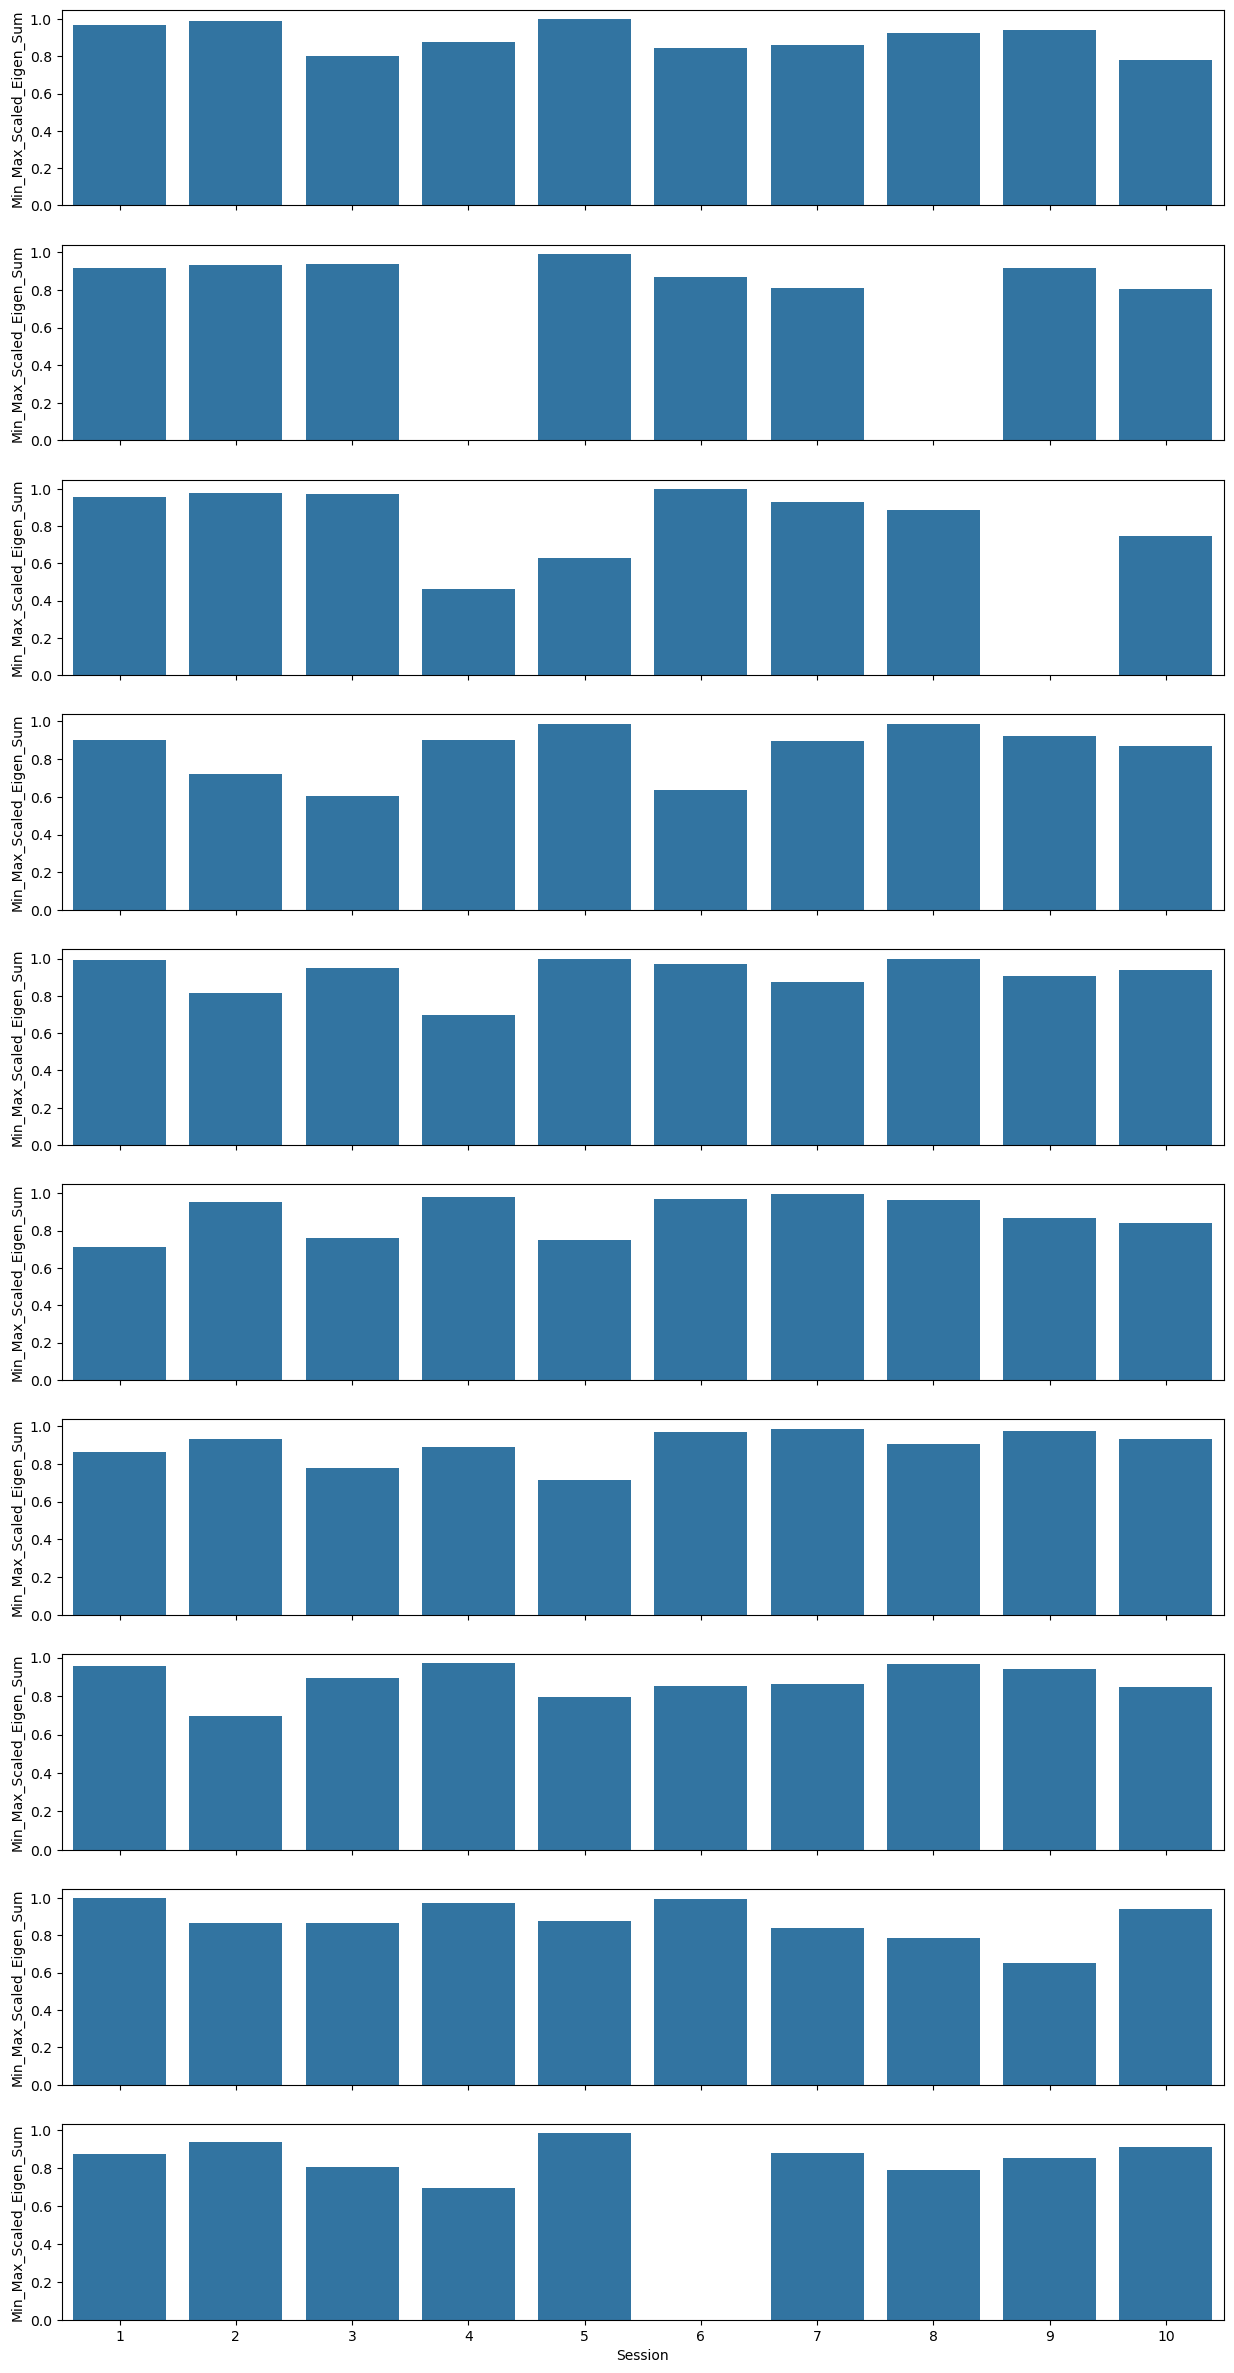

In [44]:
fig, ax = plt.subplots(10,1, figsize=(15,30), sharex=True)

for subj in range(1,11):
    sns.barplot(data=evaldf[evaldf['Subject']==subj], x='Session', y='Min_Max_Scaled_Eigen_Sum', ax=ax[subj-1])

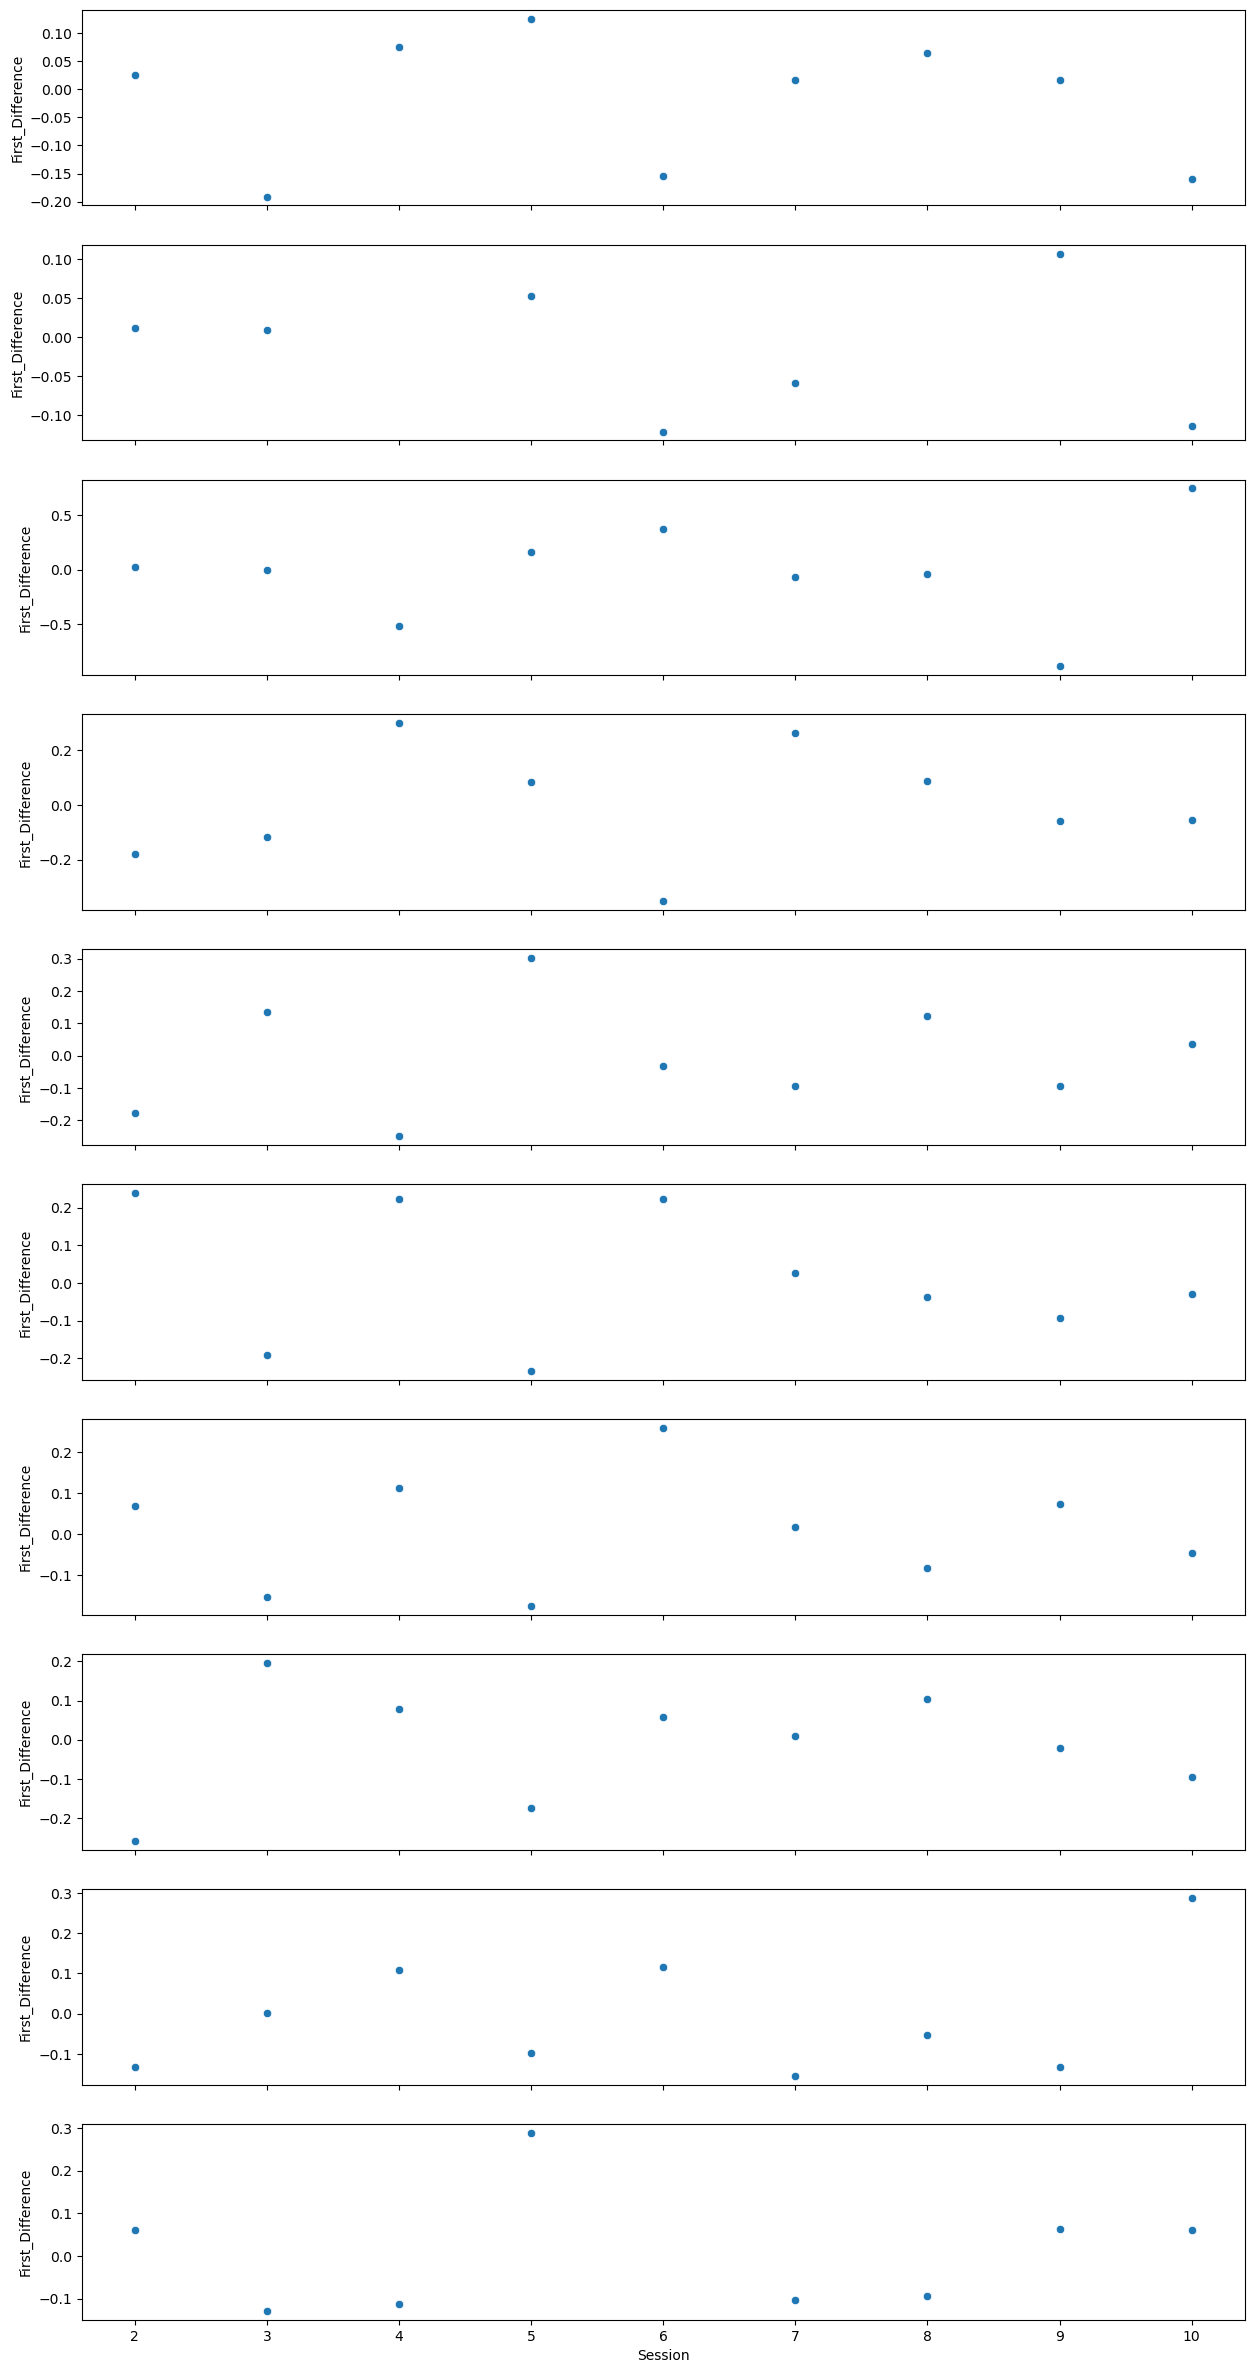

In [45]:
fig, ax = plt.subplots(10,1, figsize=(15,30), sharex=True)

for subj in range(1,11):
    data=evaldf[evaldf['Subject']==subj].copy()
    data['First_Difference'] = data['Min_Max_Scaled_Eigen_Sum'].diff()
    sns.scatterplot(data=data, x='Session', y='First_Difference', ax=ax[subj-1])

In [113]:
df_list = []
for sub in range(1,11):
    
    data = evaldf[evaldf['Subject']==sub].copy()
    data = data.reset_index(drop=True)
    if sub==10:
        sub = str(sub)
    else:
        sub = "0"+str(sub)
    

    p_scan_dates = os.path.join(config['raw_dir'], config['subj_prefix']+sub, "_".join([config['subj_prefix']+sub, 'sessions.tsv']))

    if not os.path.isfile(p_scan_dates):
        print(f"Failed: {p_scan_dates}")
        continue

    df = pd.read_csv(p_scan_dates, header=0, sep="\t")
    df = df[df['session_id'].map(len)<=10]
    df['Session'] = df['session_id'].map(lambda x: int(x[-2:]))
    df['Subject'] = [int(sub)]*df.shape[0]
    
    df['Acquisition_Time'] = pd.to_datetime(df['acq_time'])
    df['Acquisition_Time_Difference'] = df['Acquisition_Time'].diff()
    df['Time_Difference_in_Hours'] = df['Acquisition_Time_Difference']/pd.Timedelta(hours=1)
    df['Scaled_Time_Difference'] = (df['Time_Difference_in_Hours']-df['Time_Difference_in_Hours'].min())/(df['Time_Difference_in_Hours'].max()-df['Time_Difference_in_Hours'].min())

    df = pd.merge(df, data[['Session', 'Min_Max_Scaled_Eigen_Sum']], on='Session', how='left')
    df['Eigenvalue_Sum_First_Difference'] = df['Min_Max_Scaled_Eigen_Sum'].diff()
    df.to_csv(os.path.join(config['data_output_dir'], "_".join([config['subj_prefix']+str(sub), "desc-ScanAcq.csv"])))

    df_list.append(df)

In [98]:
# uncomment out below if necessary to create df_list
# df_list = []
corr_list = []

for i in range(10):
    # uncomment below if df_list isn't available
    # df = pd.read_csv(os.path.join(config['data_output_dir'], "_".join([config['subj_prefix']+str(sub), "desc-ScanAcq.csv"])), index_col=0, header=0)
    # df_list.append(df)

    # comment out below if reading directly from file and creating df_list
    df = df_list[i]
    # we are first gonna drop our nans
    df_no_nans = df.dropna(axis=0)

    corrlist = [df_no_nans['Scaled_Time_Difference'], df_no_nans['Eigenvalue_Sum_First_Difference']]
    correlation_matrix = np.corrcoef(corrlist[0], corrlist[1])
    print(f"The correlation between acquisition time and volume change for Subject {i+1} is: {correlation_matrix[0][1]} \n")
    corr_list.append(correlation_matrix[0][1])

The correlation between acquisition time and volume change for Subject 1 is: 0.2686651640434013 

The correlation between acquisition time and volume change for Subject 2 is: 0.6385122610156432 

The correlation between acquisition time and volume change for Subject 3 is: -0.0367180937355016 

The correlation between acquisition time and volume change for Subject 4 is: 0.2160969119072226 

The correlation between acquisition time and volume change for Subject 5 is: 0.16071110349860301 

The correlation between acquisition time and volume change for Subject 6 is: -0.18959491948374163 

The correlation between acquisition time and volume change for Subject 7 is: -0.3774516380672181 

The correlation between acquisition time and volume change for Subject 8 is: 0.6331578833264396 

The correlation between acquisition time and volume change for Subject 9 is: -0.5039201523950495 

The correlation between acquisition time and volume change for Subject 10 is: 0.2878351115464176 



In [114]:
timedf = pd.concat(df_list)
timedf = timedf.reset_index(drop=True)

In [119]:
timedf.to_csv("./datasets/Acq_Time_Eigen_Sum_rFEF.csv")

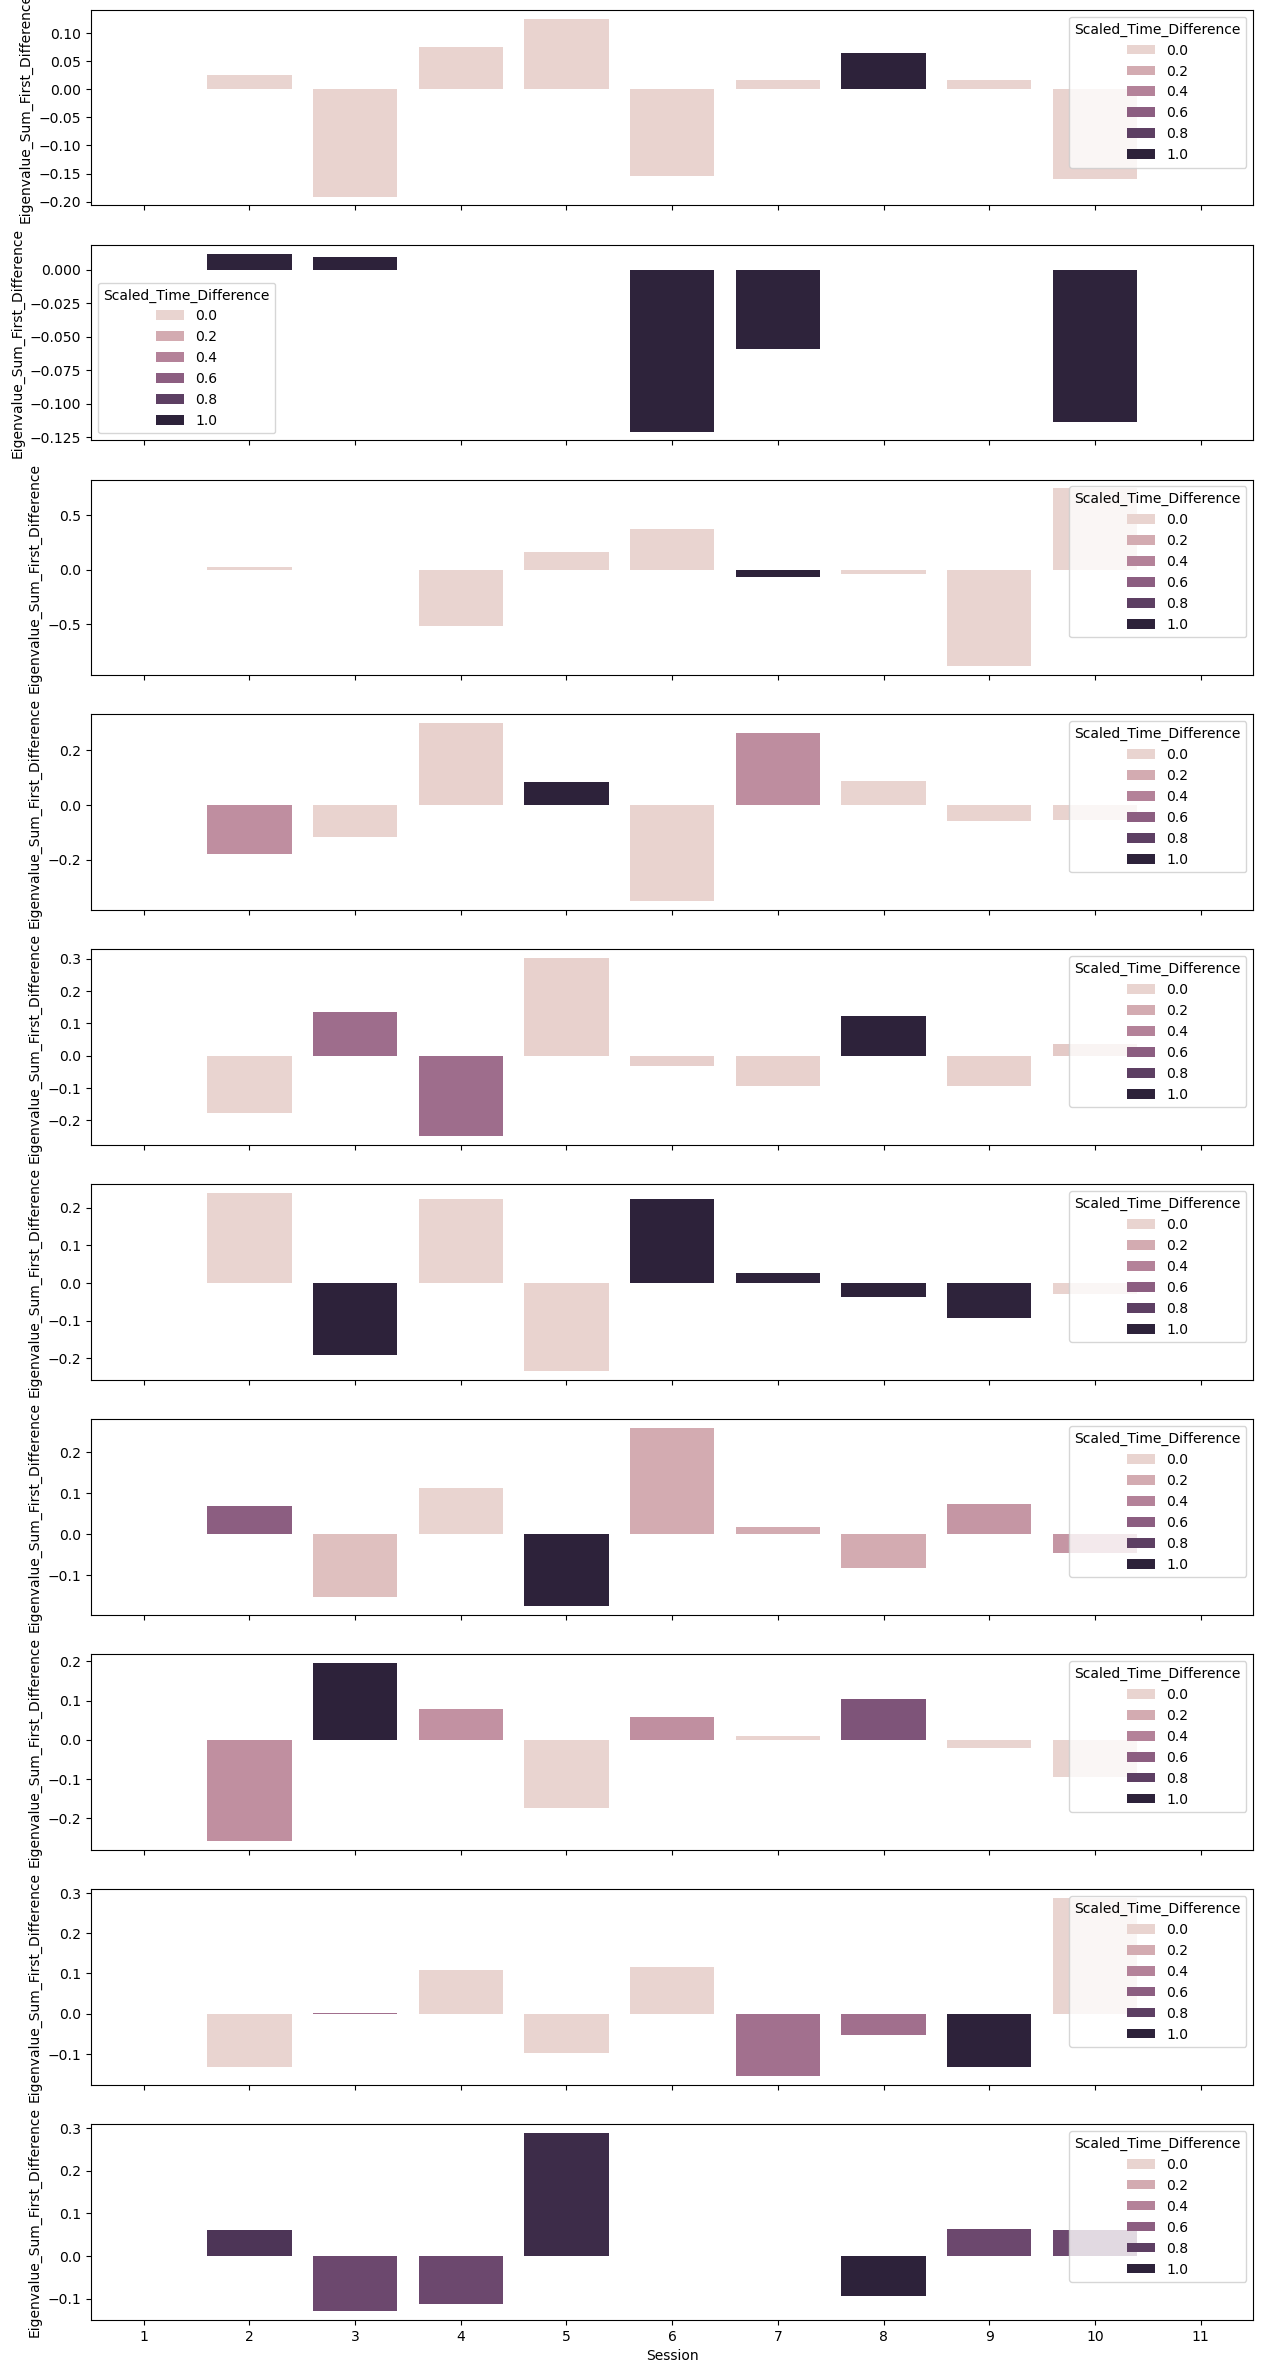

In [128]:
fig, ax = plt.subplots(10,1, figsize=(15,30), sharex=True)

for subj in range(1,11):
    sns.barplot(data=timedf[timedf['Subject']==subj], x='Session', y='Eigenvalue_Sum_First_Difference', hue='Scaled_Time_Difference', dodge=False, ax=ax[subj-1])
    # sns.scatterplot(data=timedf[timedf['Subject']==subj], x='Session', y='Scaled_Time_Difference', ax=ax[subj-1])

There is no linear relationship between scan acquisition time and manifold volume, though there does appear to be some kind of effect regardless.

In [122]:
from sklearn.neural_network import MLPRegressor

In [ ]:
results = []

# 1. Loop through each potential "Template" (Subject)
for template_id in subjects:
    
    # Get the Template Data (Z-scored)
    template_data = get_data_for_subject(template_id)
    
    # METRIC A: Signal Quality (Does this template actually know Indoor vs Outdoor?)
    # (Pseudo-code for the logic we discussed)
    indoor_vec = template_data[indoor_mask].mean(axis=0)
    outdoor_vec = template_data[outdoor_mask].mean(axis=0)
    signal_strength = np.linalg.norm(indoor_vec - outdoor_vec)
    
    # METRIC B: Group Similarity (Can everyone else align to this?)
    total_correlation = 0
    
    for source_id in subjects:
        if source_id == template_id: continue
        
        source_data = get_data_for_subject(source_id)
        
        # Procrustes Align Source -> Template
        R, _ = orthogonal_procrustes(source_data, template_data)
        aligned_source = source_data @ R
        
        # Add to correlation sum
        corr = np.corrcoef(aligned_source.flatten(), template_data.flatten())[0,1]
        total_correlation += corr
        
    # Store everything in a dictionary (Self-documenting!)
    results.append({
        'Template_ID': template_id,
        'Group_Correlation': total_correlation,   # High = Central (or Generic)
        'Signal_Strength': signal_strength        # High = Expert
    })

# Convert to DataFrame for easy analysis
results_df = pd.DataFrame(results)